α = 0.4
  Ajuste MSD(t) ≈ A log(t) + B con:
    A = 0.874921, B = 0.387257
  Prefactor teórico de log(t): α(1-q)/q = 0.600000

 Prefactor de 1/t: α(α-1)(1-q)/q^2 -0.8999999999999998

α = 1.2
  Ajuste MSD(t) ≈ A log(t) + B con:
    A = 3.125227, B = -5.795874
  Prefactor teórico de log(t): α(1-q)/q = 1.800000

 Prefactor de 1/t: α(α-1)(1-q)/q^2 0.8999999999999996

α = 2.5
  Ajuste MSD(t) ≈ A log(t) + B con:
    A = 6.707128, B = -17.263352
  Prefactor teórico de log(t): α(1-q)/q = 3.750000

 Prefactor de 1/t: α(α-1)(1-q)/q^2 14.062499999999996

α = 0.4
  Ajuste MSD(t) ≈ A log(t) + B con:
    A = 0.503250, B = 1.089831
  Prefactor teórico de log(t): α(1-q)/q = 0.600000

 Prefactor de 1/t: α(α-1)(1-q)/q^2 -0.8999999999999998

α = 1.2
  Ajuste MSD(t) ≈ A log(t) + B con:
    A = 1.422973, B = -0.642407
  Prefactor teórico de log(t): α(1-q)/q = 1.800000

 Prefactor de 1/t: α(α-1)(1-q)/q^2 0.8999999999999996

α = 2.5
  Ajuste MSD(t) ≈ A log(t) + B con:
    A = 2.686254, B = -2.927348
  Prefac

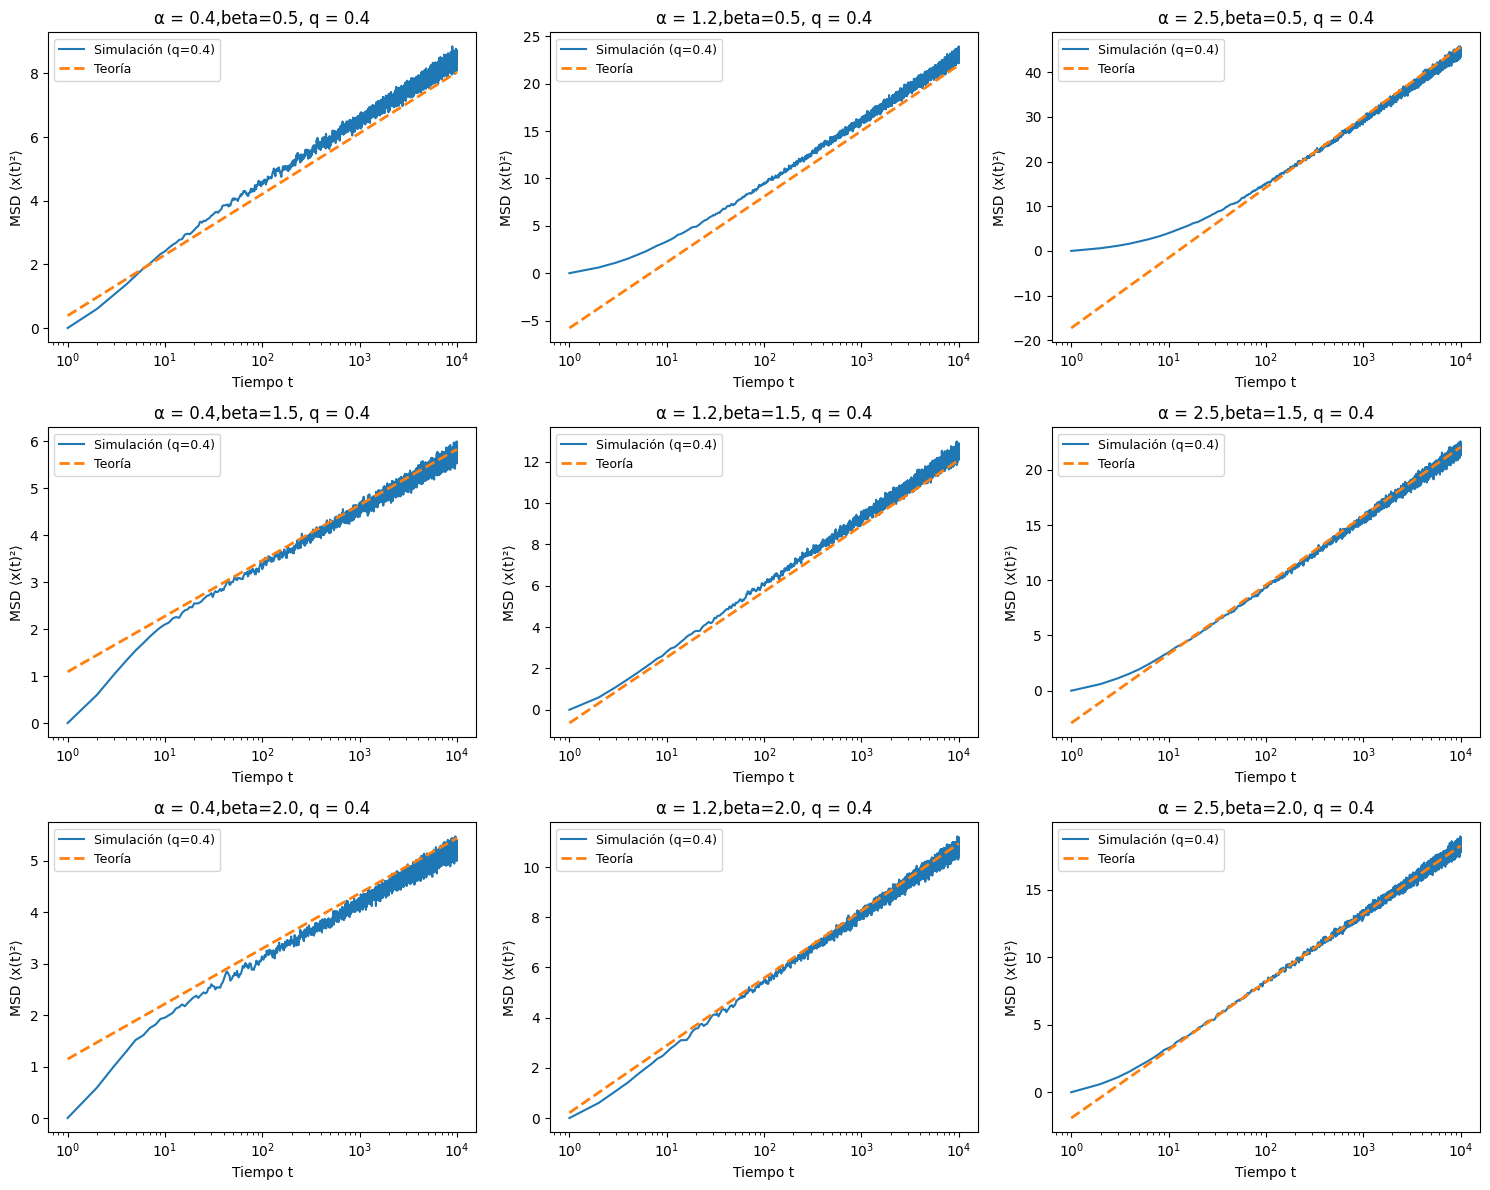

[1.7616933818200455, -4.421437696832604, -15.888916396768868, 2.4642668043978033, 0.7320290863114781, -1.5529122883127355, 2.52046985944576, 1.5847200129331458, -0.5347559448128925]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp

if __name__ == "__main__":
    gam= 0.57721566490153286060651209
    n_cases = len([0.2, 0.5, 1.2, 1.5, 1.7, 2.0, 2.0, 3.0])
    n_cols = 3
    n_rows = int(np.ceil(n_cases / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten()
    # Ejemplo de uso: caso especial alpha=2, beta=1
    T = 10000
    n_traj = 5000
    q = 0.2
    alpha = 0.4
    beta = 1.0
    p = 0.5
    Rs = []
    vars = []

    # Tiempo mínimo a partir del cual hacemos el ajuste (ajústalo a tu gusto)
    # Por ejemplo, a partir de t = 100
    t_fit_min = 6000
    yayo = False
    # for alpha in [0.2,0.5,1.0,1.2, 1.5, 1.7, 2.0, 2.5,3.0]:
    for beta in [0.5, 1.5, 2.0]:
        for alpha in [0.4,1.2,2.5]:
            if alpha == 2.0 and yayo == True:
                q = 0.7
                msd = np.load(f"betha_1/msd_beta_binomial_{str(alpha)[0]}_{str(alpha)[-1]}_07.npy")
                yayo = False
            else:
                q = 0.4
                # msd = np.load(f"betha_1/msd_beta_binomial_{alpha:.2f}_v2.npy")
                # msd = np.load(f"alpha_1/msd_beta_binomial_{str(beta)[0]}_{str(beta)[-1]}.npy")
                msd = np.load(f"general_MSD/msd_beta_binomial_a_{str(alpha)[0]}_{str(alpha)[-1]}_b_{str(beta)[0]}_{str(beta)[-1]}.npy")

            # t desde 1 hasta len(msd), para evitar log(0)
            t = np.arange(1, len(msd) + 1, dtype=float)
            t_= np.arange(1, len(msd) + 1, dtype=float) 

            # ---------
            # Ajuste logarítmico MSD(t) ~ A log(t) + B
            # ---------
            mask = t >= t_fit_min
            x = np.log(t[mask])   # variable independiente: log t
            y = msd[mask]         # variable dependiente: MSD

            # polyfit grado 1: y ≈ A * x + B
            A, B = np.polyfit(x, y, 1)
            # MSD teórica:
            # para t grande, el término dominante es ~ (alpha*(1-q)/q) * log(q t)
            m = -11.773794979615863 
            n = 11.408403049648689
            if alpha < 0:
                msd_theory = (
                    np.log(t_) * alpha * (1 - q) / q 
                    + alpha * (alpha - 1) * (1 - q) / (t_ * q**2) 
                    # + m*alpha + n
                    +B
                    # + ((1 - q)/ q)*np.log(q) #+ ((1 - q)/ q)*gam
                )
            elif beta > 0.4:
                a = -(1-q)/(q*( mp.digamma(alpha) - mp.digamma(beta+alpha)))
                msd_theory = (np.log(t_)*a + B)
            else:
                msd_theory = alpha*((1 - q)/ q)*np.log(t_) +  ((1 - q)/ q)*np.log(q) + ((1 - q)/ q)*gam

            R = B - ( ((1 - q)/ q)*np.log(q))# + ((1 - q)/ q)*gam)
            # Rs.append(np.mean(R[mask]))
            Rs.append(R)

            # MSD ajustada para todo el rango (y sirve para extrapolar)
            msd_logfit = A * np.log(t_) + B

            print(f"α = {alpha}")
            print(f"  Ajuste MSD(t) ≈ A log(t) + B con:")
            print(f"    A = {A:.6f}, B = {B:.6f}")
            print(f"  Prefactor teórico de log(t): α(1-q)/q = {alpha*(1-q)/q:.6f}\n")
            print(f" Prefactor de 1/t: α(α-1)(1-q)/q^2 {alpha * (alpha - 1) * (1 - q) / (q**2)}\n")

            idx = len(Rs) - 1  # índice del subplot actual

            ax = axes[idx]
            # ax.plot(t_, R)
            ax.plot(t, msd, label=f"Simulación (q={q})")
            ax.plot(t_, msd_theory, lw=2, ls="--", label="Teoría")
            # ax.axhline(((1 - q)/ q)*np.log(q) + ((1 - q)/ q)*gam)
            # ax.axhline(B,color = 'red')
            ax.set_xscale("log")
            ax.set_xlabel("Tiempo t")
            ax.set_ylabel("MSD ⟨x(t)²⟩")
            ax.set_title(f"α = {alpha},beta={beta}, q = {q}")
            ax.legend(fontsize=9)

    # Apaga subplots vacíos
    for j in range(idx + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    print(Rs)

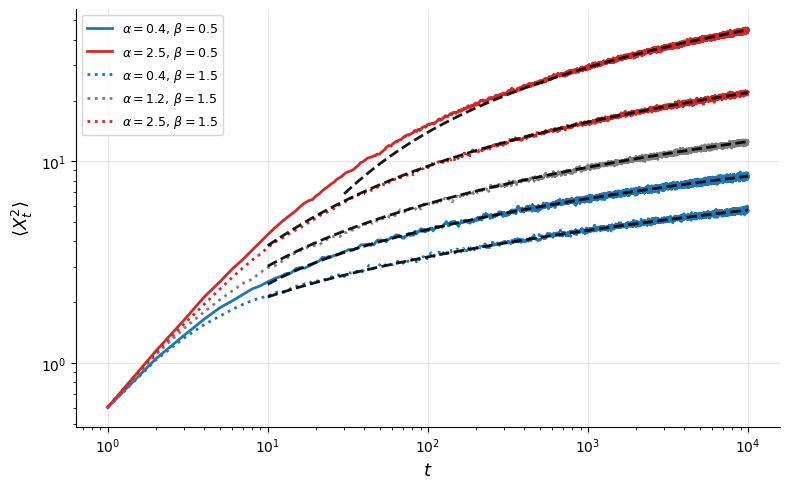

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp

if __name__ == "__main__":
    gam = 0.57721566490153286060651209

    # Parámetros
    q = 0.4
    alphas = [0.4, 1.2, 2.5]
    betas = [0.5, 1.5]

    # --- Ordenadas al origen propuestas manualmente ---
    B_manual = {
        (0.4, 0.5): 0.787257,
        (0.4, 1.5): 0.989831,
        (1.2, 0.5): -5.795874,
        (1.2, 1.5): -0.210284,
        (2.5, 0.5): -18.05,
        (2.5, 1.5): -3.109192,
    }

    # --- Inicio manual de la curva teórica ---
    # Aquí decides desde qué valor de t empieza a dibujarse la teoría
    t_start_manual = {
        (0.4, 0.5): 10,
        (0.4, 1.5): 10,
        (1.2, 0.5): 10,
        (1.2, 1.5): 10,
        (2.5, 0.5): 30,
        (2.5, 1.5): 10,
    }

    # Colores para alpha
    color_map = {
        0.4: "tab:blue",
        1.2: "tab:gray",
        2.5: "tab:red",
    }

    # Tipos de línea para beta
    linestyle_map = {
        0.5: "-",
        1.5: ":",
    }

    plt.figure(figsize=(8,5))

    for beta in betas:
        for alpha in alphas:
            if alpha == 1.2 and beta == 0.5:
                continue
            # Cargar MSD simulado
            msd = np.load(
                f"general_MSD/msd_beta_binomial_a_{str(alpha)[0]}_{str(alpha)[-1]}_b_{str(beta)[0]}_{str(beta)[-1]}.npy"
            )

            # Tiempo
            t = np.arange(1, len(msd) + 1, dtype=float)

            # Ordenada al origen manual
            B = B_manual[(alpha, beta)]

            # Inicio manual de la teoría
            t_start = t_start_manual[(alpha, beta)]

            # Prefactor teórico
            a = -(1 - q) / (q * (mp.digamma(alpha) - mp.digamma(alpha + beta)))
            a = float(a)
            c = (q-1)*(alpha-1) /(beta*q**2 * (mp.digamma(alpha) - mp.digamma(alpha + beta)))

            # MSD teórico
            if alpha > 0.3:
                msd_theory = a * np.log(t) + B + c/t
            else:
                msd_theory = a * np.log(t) + B

            color = color_map[alpha]
            ls_sim = linestyle_map[beta]

            # Simulación
            plt.plot(
                t[:-1],
                msd[1:],
                color=color,
                ls=ls_sim, 
                lw=2,
                label=fr"$\alpha={alpha},\,\beta={beta}$"
            )

            # Graficar teoría solo desde t_start
            mask_theory = t >= t_start
            plt.plot(
                t[mask_theory],
                msd_theory[mask_theory],
                color='black',
                ls="--",
                lw=2,
                alpha=0.9,
                # label=fr"Teo: $\alpha={alpha},\,\beta={beta}$"
            )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("$t$", fontsize=13)
    plt.ylabel(r"$\langle X_t^2 \rangle$", fontsize=13)
    # plt.title(r"MSD simulada y teórica para distintas combinaciones de $\alpha$ y $\beta$", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=9, ncol=1)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

[-1.23950151 -7.64894444 11.08427406]


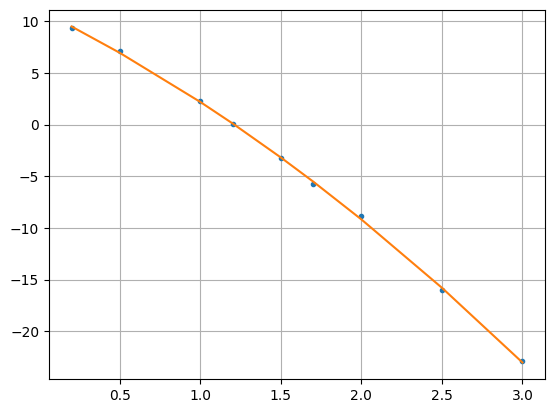

In [93]:
alpha = [0.2,0.5,1.0,1.2, 1.5, 1.7, 2.0,2.5, 3.0] # q = 0.2
Bs = [3.020243986390917, 0.791078554956384, -6.107619405996664, -10.058756837283601, -11.834810456221627, -16.293028299848373, -30.002801776050696]
Rs = [9.376029503594319, 7.083476604707688, 2.3179175352649635, 0.11008336350566061, -3.2540836894139753, -5.71621001745257, -8.854613271667116, -16.027823156157496, -22.917235716795833]

# Rs = np.array(Rs) + 0.22417558655393943


coef = np.polyfit(alpha, Rs, 2)
print(coef)
A, B,C = coef
coef = [-1.2395015110156924, -7.648944440355316 ,11.084274058129283]
y_fit = np.polyval(coef, alpha)

plt.plot(alpha,Rs,'.')
plt.grid()
plt.plot(alpha, y_fit, '-')